In [47]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [48]:
train_set = "/Users/josephledford/Downloads/Housing Prices Competition/train.csv"
df = pd.read_csv(train_set)
df.shape
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

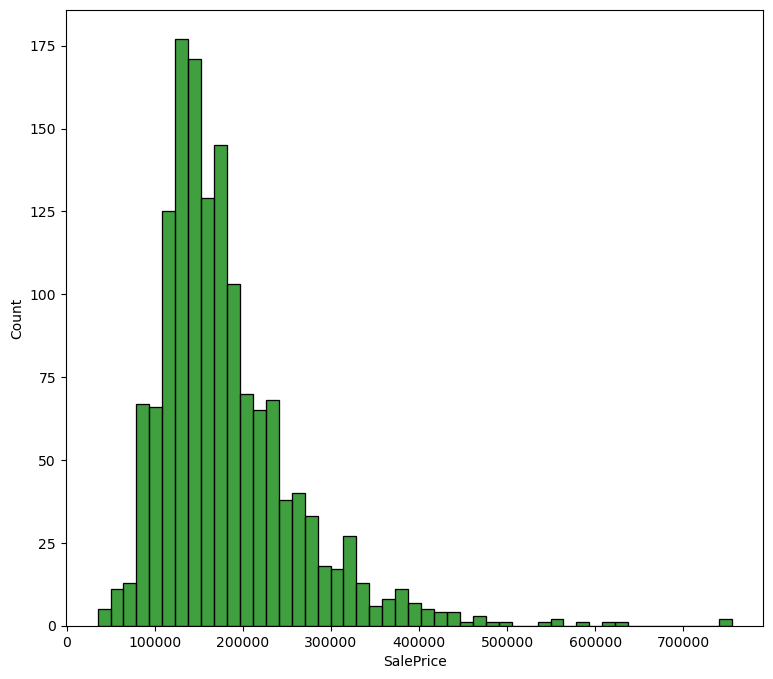

In [50]:
print(df['SalePrice'].describe())
plt.figure(figsize=(9,8))
sns.histplot(df['SalePrice'], color="g", bins='auto', line_kws={'alpha':0.4} )

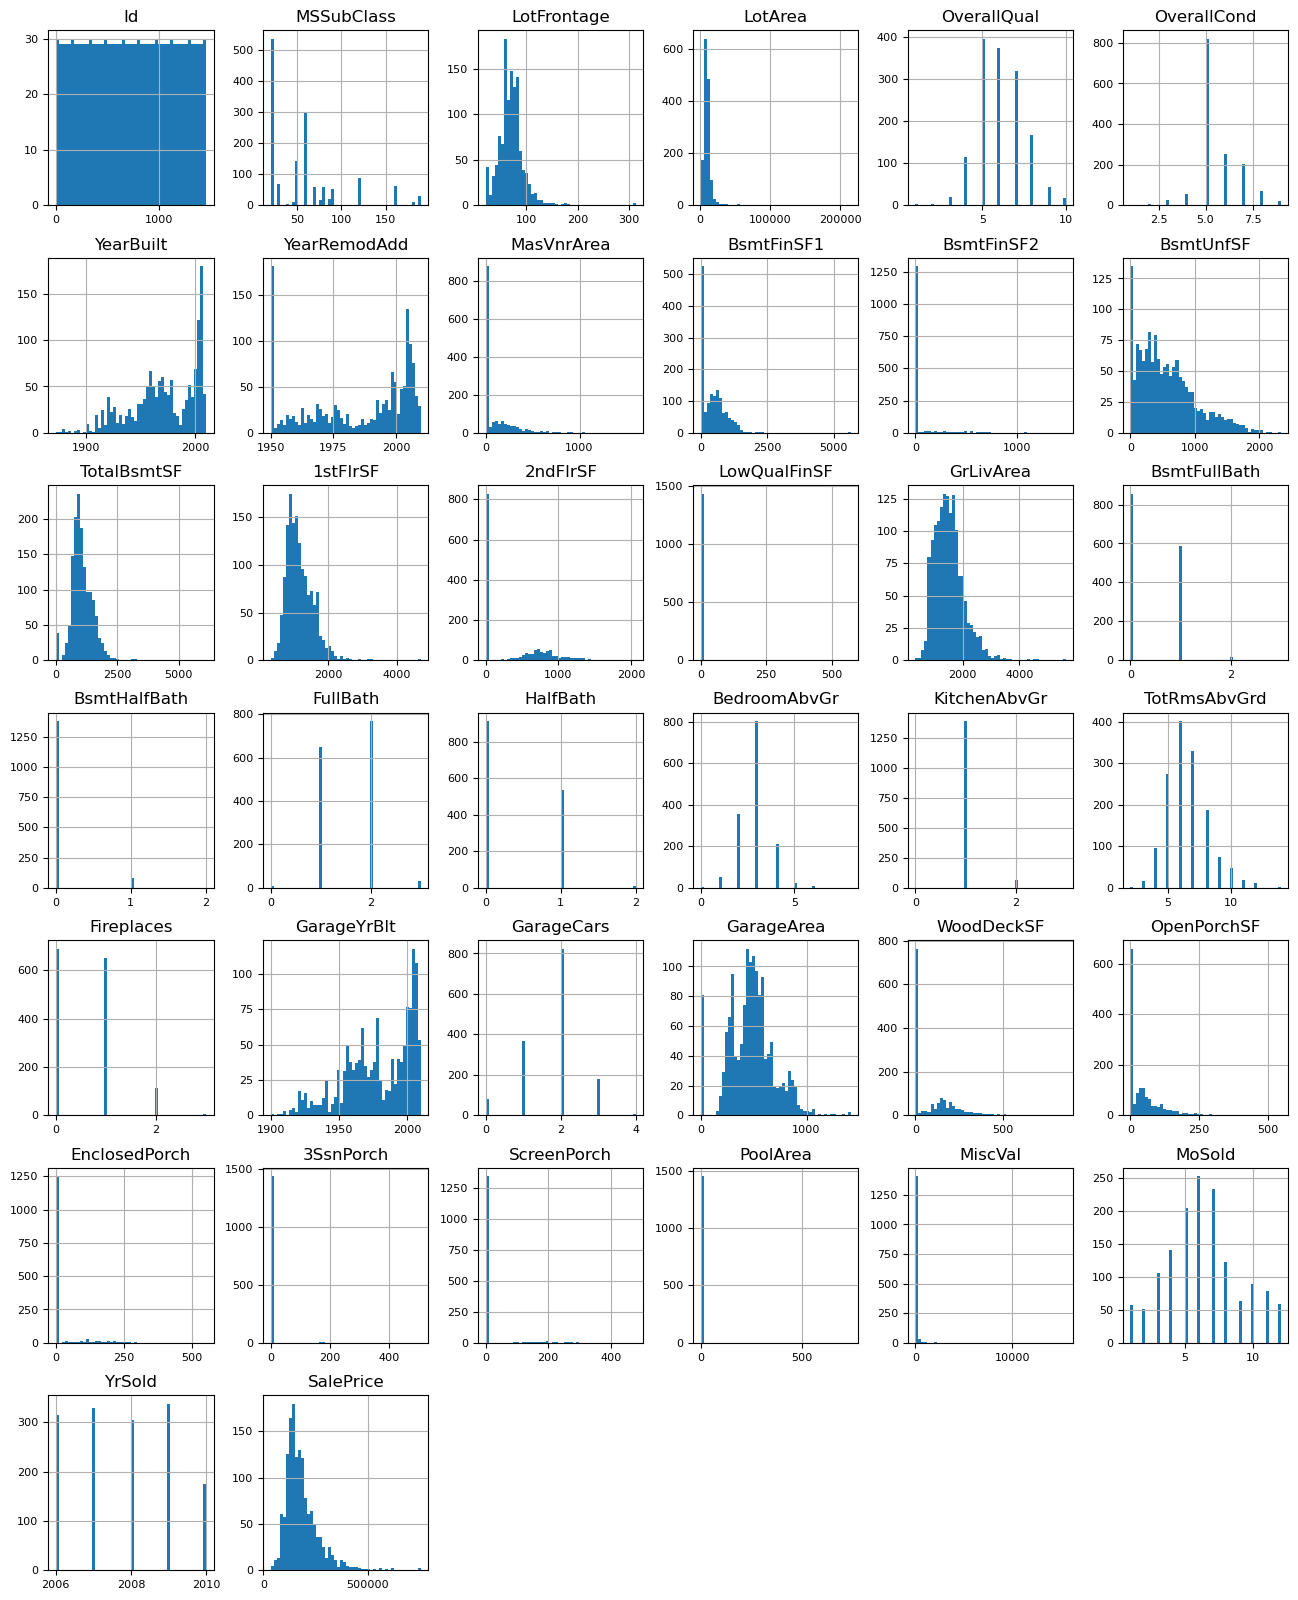

In [51]:
df_num = df.select_dtypes(include=['float64', 'int64'])
df_num.hist(figsize=(16,20), bins=50, xlabelsize=8, ylabelsize=8);

In [52]:
train_set, valid_set = train_test_split(df, test_size=0.3, random_state=42)
print(f"{len(train_set)} in training, {len(valid_set)} in testing")

1022 in training, 438 in testing


In [56]:
label = 'SalePrice'

train_X = train_set.drop(columns=[label])
train_y = train_set[label]
valid_X = valid_set.drop(columns=[label])
valid_y = valid_set[label]

combo = pd.concat([train_X, valid_X])
combo_encode = pd.get_dummies(combo, drop_first=True)

train_X_encode = combo_encode.iloc[:len(train_X), :]
valid_X_encode = combo_encode.iloc[len(train_X):, ]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(train_X_encode, train_y)

preds = rf.predict(valid_X_encode)

submission = pd.DataFrame({
   "Id": valid_set["Id"],
   "SalePrice": preds
   })

print(submission.head())

        Id   SalePrice
892    893  138660.450
1105  1106  314775.895
413    414  118282.560
522    523  149696.775
1036  1037  318647.805
